# Lección 8 (parte 2) - SARIMAX: SARIMA con variables exógenas

En esta segunda parte veremos cómo implementar de forma práctica un modelo SARIMAX con ayuda de las librerías StatsForecas y MLForecast.

La implementación será muy similar a la que vimos para ARIMAX en la lección 7, así que nos enfocaremos principalmente en las diferencias que existen en este caso, teniendo en cuenta el componente estacional de la Serie.

## 1. Importación de librerías

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Modelo de regresión <--------
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast

# Modelo ARIMA con stasforecast
from statsforecast import StatsForecast
from statsforecast.models import ARIMA

RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/45-2026-03-ARIMA/data/'

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 4)

## 2. El set de datos y el problema a resolver

Usaremos el set de datos "demanda_eletricidad_sarimax.csv" que contiene el registro histórico del nivel de demanda de electricidad por hora (MW/h) de una  de una ciudad durante el último año.

Además de esto, contamos con datos de la temperatura horaria durante el mismo periodo de tiempo. Esta temperatura será nuestra variable exógena en este caso.

Así que el problema a resolver será:

> Construir un modelo SARIMAX para pronosticar el nivel de demanda con un horizonte de 7 días, que incorpore no sólo el comportamiento histórico de la Serie sino también la variable exógena

Comencemos leyendo el set de datos:

In [2]:
# Leer dataset
df = pd.read_csv(RUTA + 'demanda_electricidad_sarimax.csv', parse_dates=['ds'])
df

,unique_id,ds,temperatura,y
0,demanda_electricidad,2025-01-01,15.7,131.2
1,demanda_electricidad,2025-01-02,15.0,135.1
2,demanda_electricidad,2025-01-03,16.3,129.1
3,demanda_electricidad,2025-01-04,17.8,117.4
4,demanda_electricidad,2025-01-05,15.3,120.7
...,...,...,...,...
360,demanda_electricidad,2025-12-27,14.9,124.9
361,demanda_electricidad,2025-12-28,16.6,119.8
362,demanda_electricidad,2025-12-29,14.3,136.9
363,demanda_electricidad,2025-12-30,15.3,136.0


Y veamos el comportamiento en el tiempo tanto de la Serie como de las temperatura:

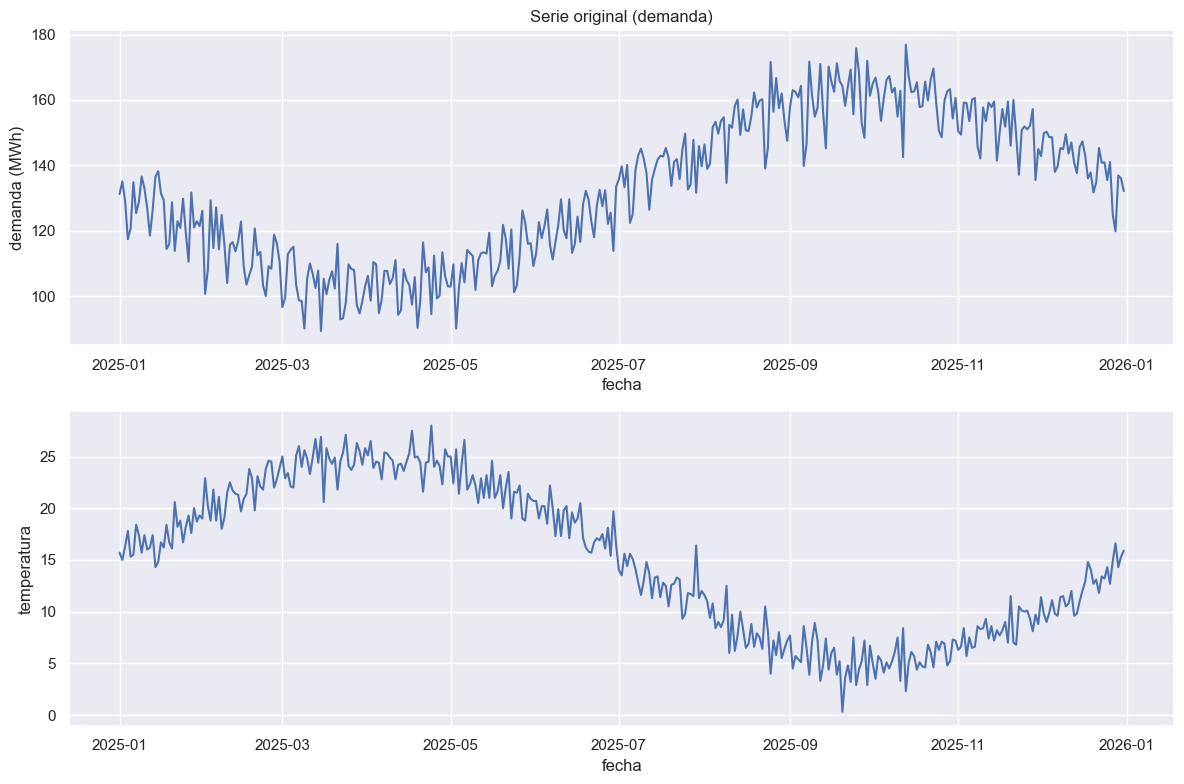

In [4]:
# Graficar serie y variables exógenas
fig, axs = plt.subplots(2,1,figsize=(12,8))

# Serie
sns.lineplot(df, x="ds", y="y", ax=axs[0])
axs[0].set_title('Serie original (demanda)')
axs[0].set_xlabel('fecha')
axs[0].set_ylabel('demanda (MWh)')

# Variable exógena (temperatura)
sns.lineplot(df, x="ds", y="temperatura", ax=axs[1])
axs[1].set_xlabel('fecha')

plt.tight_layout();

Parece haber una relación lineal inversa entre las dos variables, aunque esto lo analizaremos en un momento.

## 3. Estimación de los parámetros del modelo SARIMAX

Est fase es muy similar a la que vimos para el caso ARIMAX de la lección anterior, con algunas ligeras diferencias que resaltaremos a continuación:

1. Crear el set de entrenamiento y prueba
2. Ajustar un modelo de regresión **sobre las variables exógenas**
3. Calcular los residuales del modelo obtenido en (2)
4. 👉👉 Definir los parámetros del modelo SARIMA que se construirá **sobre los residuales obtenidos en (3)**
5. 👉👉 Habiendo definido los parámetros del modelo SARIMA (4), entrenar y validar el modelo SARIMAX
6. Generar pronósticos con el modelo obtenido en (5)

Veamos como implementar cada una de estas fases, enfocándonos en las fases 4 y 5

### 3.1. Sets de entrenamiento y prueba

El set de entrenamiento tendrá 358 registros y el set de prueba serán los 7 últimos días:

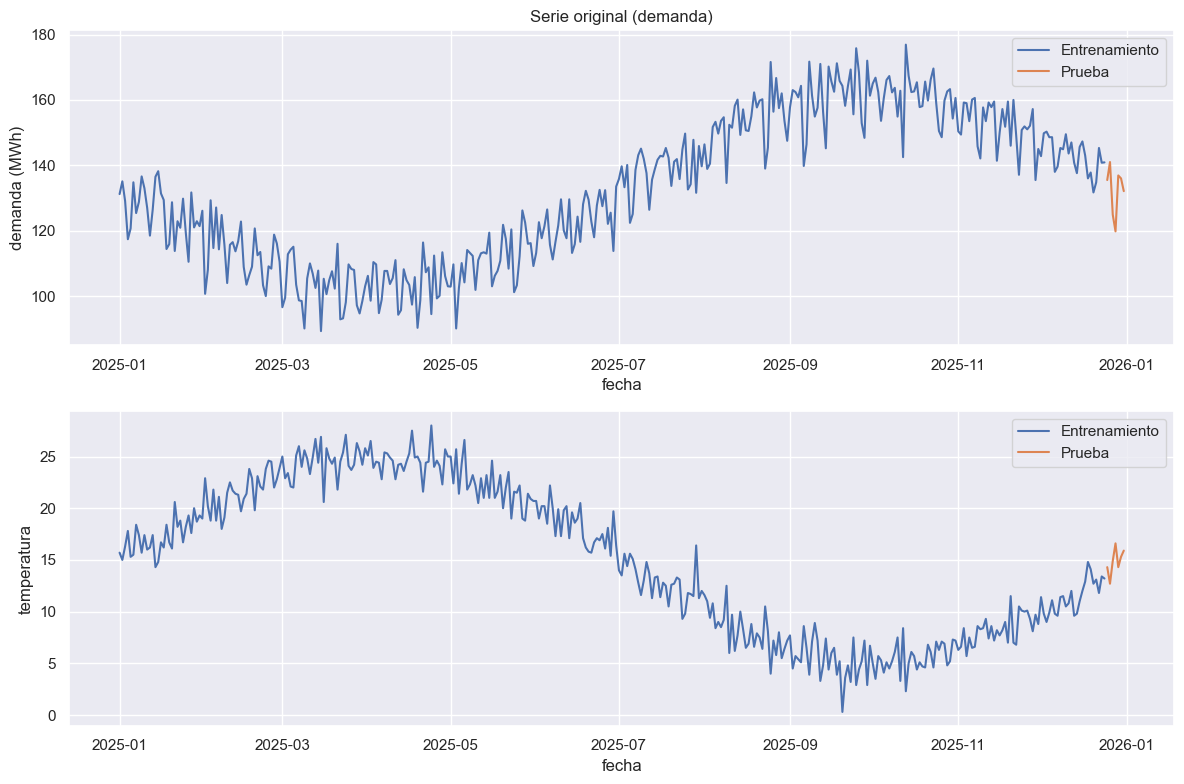

In [5]:
# Entrenamiento y prueba
df_tr = df[:358]
df_ts = df[358:] # Últimos 7 días de prueba

# Graficar
fig, axs = plt.subplots(2,1,figsize=(12,8))

# Serie
sns.lineplot(df_tr, x="ds", y="y", ax=axs[0], label='Entrenamiento')
sns.lineplot(df_ts, x="ds", y="y", ax=axs[0], label='Prueba')
axs[0].set_title('Serie original (demanda)')
axs[0].set_xlabel('fecha')
axs[0].set_ylabel('demanda (MWh)')

# Variables exógenas
sns.lineplot(df_tr, x="ds", y="temperatura", ax=axs[1], label='Entrenamiento')
sns.lineplot(df_ts, x="ds", y="temperatura", ax=axs[1], label='Prueba')

axs[1].set_xlabel('fecha')
axs[1].legend()

plt.tight_layout();

### 3.2. Modelo de regresión sobre las variables exógenas

Nuevamente usaremos lo aprendido en la lección 9 del curso "Pronósticos de Series de Tiempo con Regresión", así que reutilizaremos varias de las funciones allí implementadas.

Comencemos determinando si hay correlación entre la demanda y la temperatura:

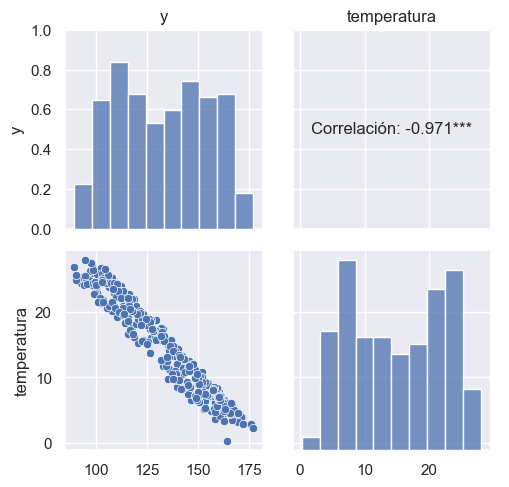

In [6]:
# Función para calcular y dibujar el nivel de correlación entre pares de variables (código tomado de la lección 9
# del curso de Pronósticos con Regresión)
def correlacion(x, y, **kws):
    # Calcular índice de correlación y valor p
    r, p = pearsonr(x, y)
    
    # Extraer axes y añadir anotación *** si el valor p es significativo
    ax = plt.gca()
    ax.annotate(f"Correlación: {r:.3f}{'***' if p < 0.05 else ''}",
               xy=(0.5, 0.5),
               xycoords = "axes fraction",
               ha = "center",
               va = "center",
    )
    
# Extraer columnas a comparar
df_plot = df_tr[["y", "temperatura"]].copy()

# Gráfico tipo Pairgrid: debajo de la diagonal -> gráficos de dispersión,
# encima de la diagonal -> Niveles de correlación
pg = sns.PairGrid(df_plot)
pg.map_diag(sns.histplot)
pg.map_upper(correlacion)
pg.map_lower(sns.scatterplot)
pg.add_legend()

# Remover etiquetas eje x
pg.set(xlabel="")

# Mover etiquetas eje "y" arriba
for i, col in enumerate(df_plot.columns):
    pg.axes[0,i].set_title(col)

Efectivamente hay una alta correlación lineal negativa. Así que un modelo de regresión lineal es perfecto en este caso:

In [7]:
# Regresión sobre variables exógenas (lección 9 curso Pronósticos con Regresión)

# Instancia del modelo
mlf = MLForecast(
    models=[LinearRegression()],
    freq = 'd'
)

# Entrenamiento
mlf.fit(df = df_tr,
        fitted = True, # Para que genere predicciones in-sample
        static_features=[] # Para que use la temperatura como una variable dinámica
       )

# Predicciones in sample
preds_is = mlf.forecast_fitted_values()

Veamos la Serie original y las predicciones in-sample:

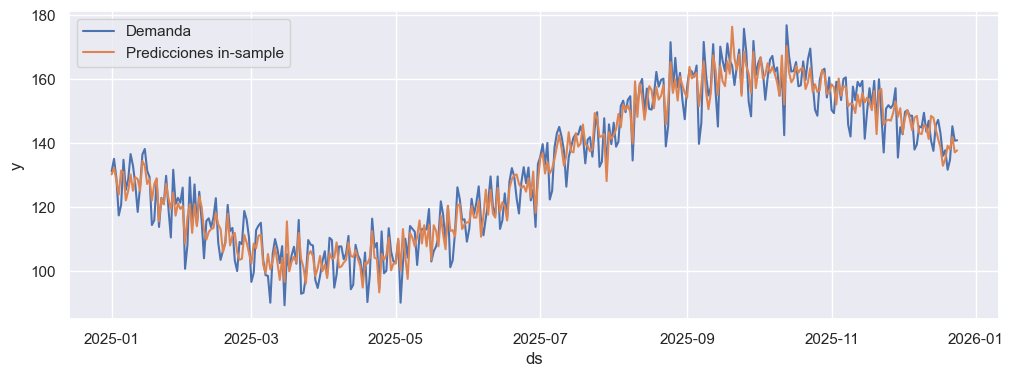

In [8]:
# Gráfico y vs. regresión variables exógenas
sns.lineplot(preds_is, x="ds", y="y", label='Demanda')
sns.lineplot(preds_is, x="ds", y="LinearRegression", label='Predicciones in-sample');

En efecto, este modelo captura buena parte de los patrones en la Serie. Lo que no logra captura será modelado por SARIMA.

### 3.3. Residuales del modelo de Regresión

Estos residuales serán el insumo del modelo SARIMA:

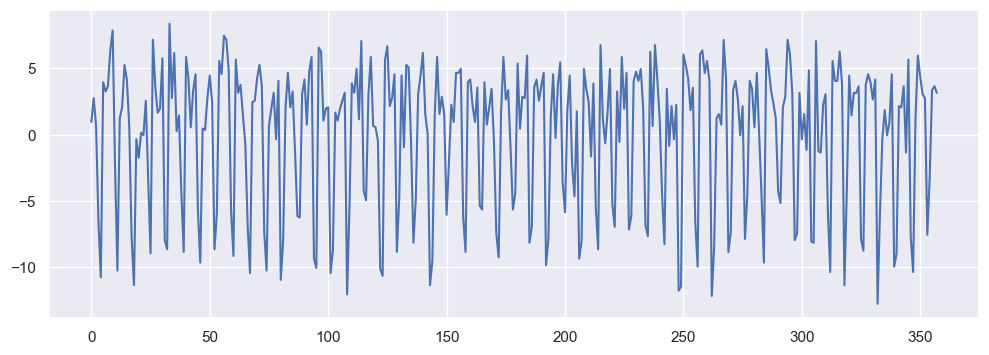

In [9]:
# Calcular residuales
res = preds_is["y"] - preds_is["LinearRegression"]
sns.lineplot(res);

Con estos residuales ya podemos determinar la estacionalidad. Así que dibujaremos la ACF de estos residuales:

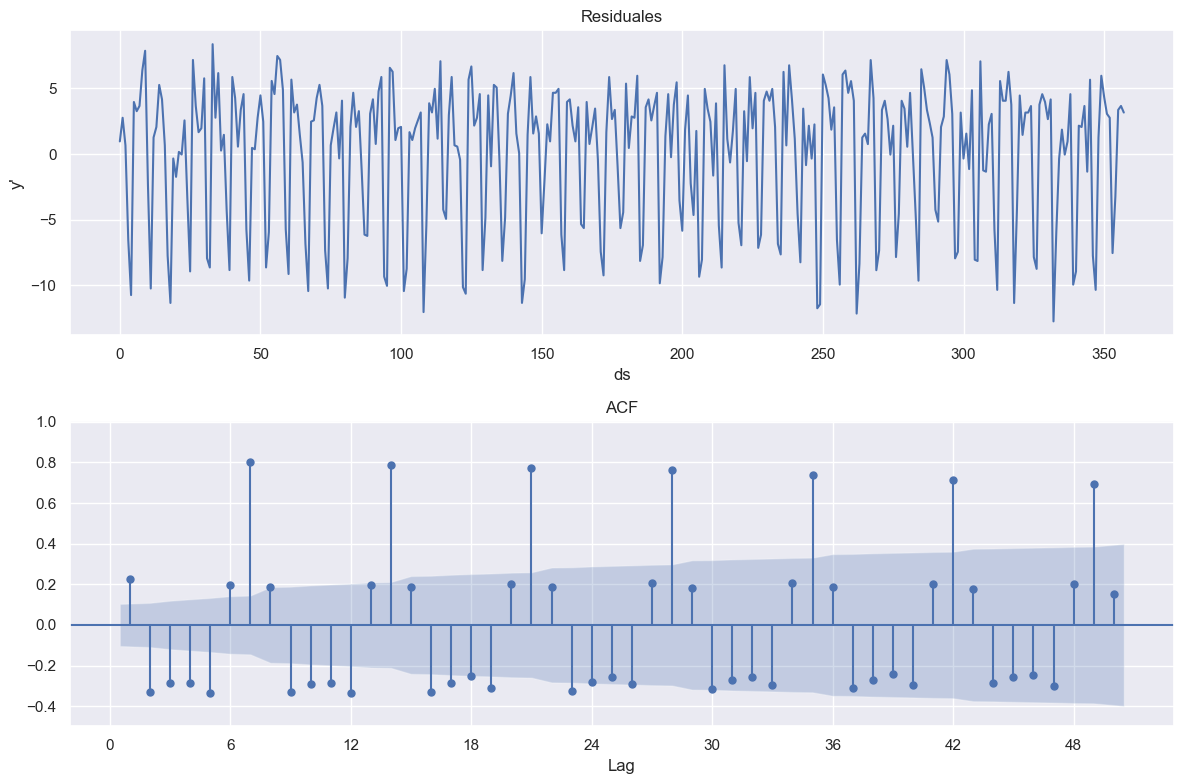

In [10]:
# Determinemos periodicidad

# Dibujar residuales y su ACF
fig, axs = plt.subplots(2,1,figsize=(12,8))

sns.lineplot(res[:], ax=axs[0])
axs[0].set_xlabel('ds')
axs[0].set_ylabel("y'")
axs[0].set_title('Residuales')

LAGS = 50
plot_acf(res,
         alpha=0.05, # Intervalo de confianza del 95%
         lags=LAGS,
         zero=False,
         auto_ylims=True,
         ax=axs[1])
axs[1].set_xlabel('Lag')
axs[1].set_xticks(range(0,LAGS+1))
axs[1].set_title('ACF')
axs[1].set_xticks(range(0, LAGS + 1, 6))
axs[1].grid(True)

plt.tight_layout()

Acá es evidente que *m=7* es decir la demanda tiene un patrón estacional semanal.

### 👉👉 3.4. Parámetros del modelo SARIMA construido a partir de los residuales

En esta parte llevamos a cabo el mismo procedimiento que vimos en lecciones anteriores para determinar los parámetros *p,d,q* y *P,D,Q* del modelo SARIMA.

Lo importante a tener en cuenta acá es que **el modelo SARIMA se construye a partir de los residuales del modelo de Regresión, NO a partir de la Serie original**.

Comencemos reutilizando la función "prueba_diferenciacion" de la lección 6 (diferenciación de órdenes *d* y *D*):

In [11]:
# La misma función usada en la lección 6
def prueba_diferenciacion(serie, m, d, D, titulo):
    # Eliminar posibles NaN de la serie
    serie = serie.dropna()
    
    # Diferenciar (si d!=0)
    if d != 0:
        for _ in range(d):
            serie = serie.diff()
    
    # Diferencia estacional (si D!=0)
    if D != 0:
        for _ in range(D):
            serie = serie.diff(m)
    
    # Aplicar prueba y mostrar resultado
    resultado = adfuller(serie.dropna())
    pval = resultado[1]
    
    if pval < 0.05:
        # Se rechaza la hipótesis nula: la serie es estacionaria
        print(f'La serie es estacionaria porque p = {pval:.2f} < 0.05. NO se requiere diferenciación')
    else:
        # Se acepta la hipótesis nula: la serie es NO estacionaria
        print(f'La serie NO es estacionaria porque p = {pval:.2f} >= 0.05. Se requiere diferenciación')
        
    # Graficar
    fig, ax = plt.subplots(1,1,figsize=(12,4))
    plt.plot(range(1,len(serie)+1), serie)
    plt.hlines(serie.mean(), xmin=1, xmax=len(serie)+1, color='red', linestyle='--');
    ax.set_title(titulo)

Veamos qué ocurre con la estacionariedad si no hacemos ninguna diferenciación:

La serie es estacionaria porque p = 0.00 < 0.05. NO se requiere diferenciación


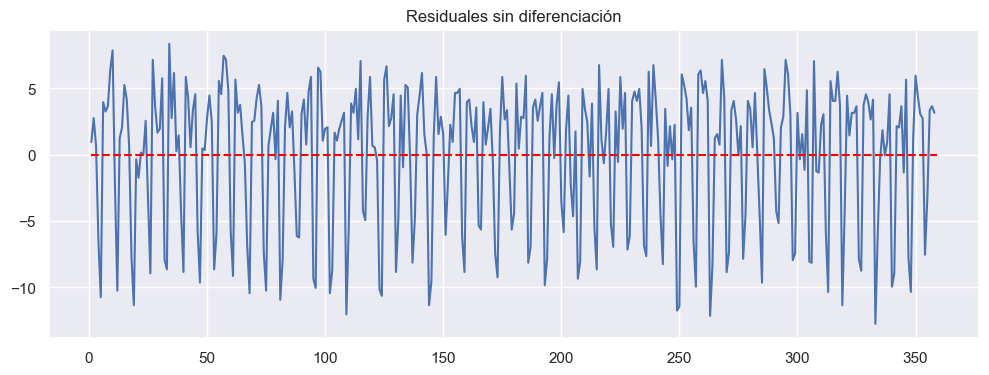

In [12]:
# Residuales sin diferenciación
prueba_diferenciacion(res, m=7, d=0, D=0, titulo='Residuales sin diferenciación');

En este caso la prueba no arroja un valor confiable, pues la serie realmente NO es estacionaria.

Veamos qué ocurre con *d=0* y *D=1*:

La serie es estacionaria porque p = 0.00 < 0.05. NO se requiere diferenciación


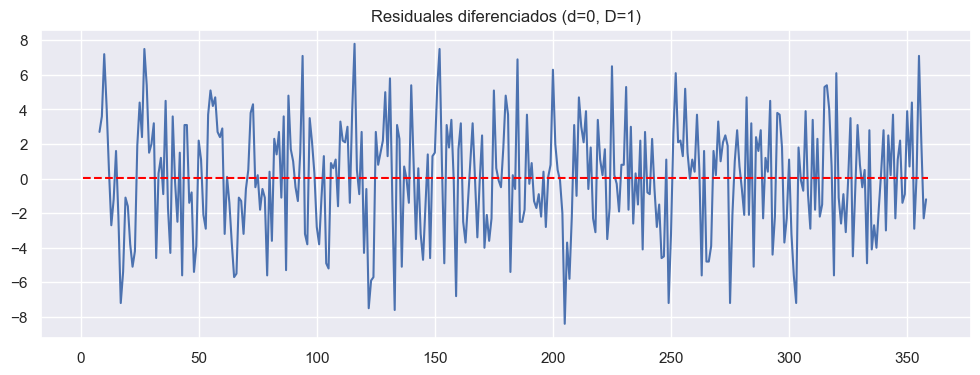

In [13]:
# Residuales con D=1
prueba_diferenciacion(res, m=7, d=0, D=1, titulo='Residuales diferenciados (d=0, D=1)');

Parece ser estacionaria. Veamos qué ocurre con *d=1* y *D=1*:

La serie es estacionaria porque p = 0.00 < 0.05. NO se requiere diferenciación


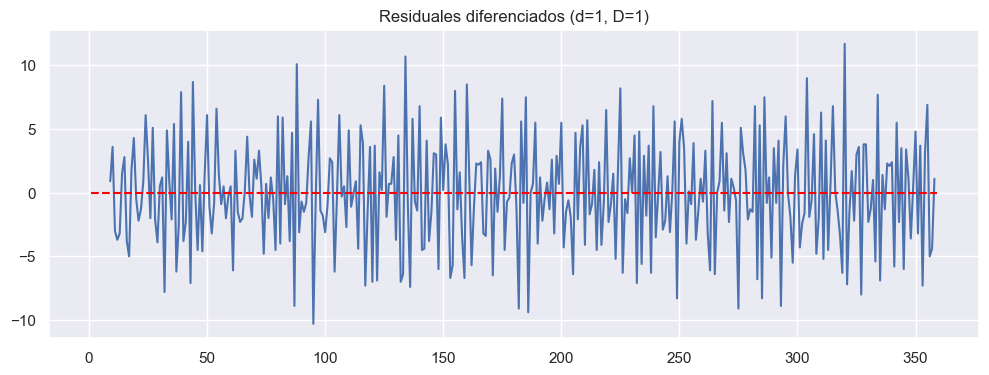

In [14]:
# Residuales con d=1, D=1
prueba_diferenciacion(res, m=7, d=1, D=1, titulo='Residuales diferenciados (d=1, D=1)');

Aunque podríamos escoger cualquiera de las dos opciones, nos inclinaremos más por *d=1* y *D=1*, pues un *d=1* parece estar más acorde con las variaciones de largo plazo de la Serie.

Veamos ahora la ACF y la PACF:

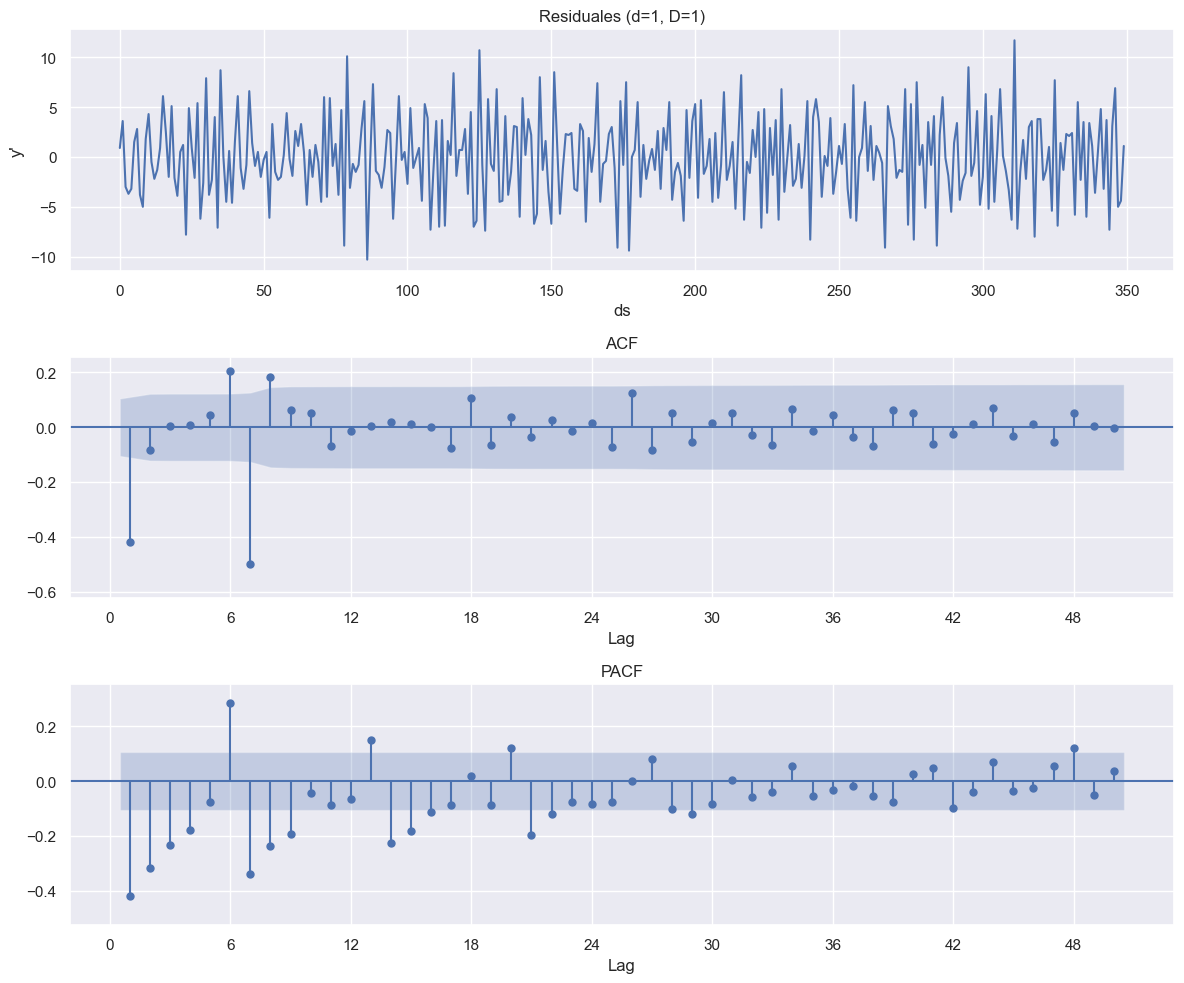

In [15]:
# ACF y PACF sobre los residuales con d=1, D=1

# Diferenciación d=1, D=1
res_diff = res.copy()
res_diff = np.diff(res_diff, n=1) # d=1
res_diff = res_diff[7:] - res_diff[:-7]

# Dibujar serie diferenciada, función de autocorrelación y PACF
fig, axs = plt.subplots(3,1,figsize=(12,10))

sns.lineplot(res_diff, ax=axs[0])
axs[0].set_xlabel('ds')
axs[0].set_ylabel("y'")
axs[0].set_title('Residuales (d=1, D=1)')

LAGS = 50
plot_acf(res_diff,
         alpha=0.05, # Intervalo de confianza del 95%
         lags=LAGS,
         zero=False,
         auto_ylims=True,
         ax=axs[1])
axs[1].set_xlabel('Lag')
axs[1].set_xticks(range(0,LAGS+1))
axs[1].set_title('ACF')
axs[1].set_xticks(range(0, LAGS + 1, 6))
axs[1].grid(True)

plot_pacf(res_diff,
          lags=LAGS,
          zero=False,
          auto_ylims=True,
          ax=axs[2])
axs[2].set_xlabel('Lag')
axs[2].set_xticks(range(0,LAGS+1))
axs[2].set_title('PACF')
axs[2].set_xticks(range(0, LAGS + 1, 6))
axs[2].grid(True)

plt.tight_layout()


Observaciones ACF:
- Claramente vemos que *q=1*
- Y además vemos un pico en el lag=7 y luego un corte abrupto en múltiplos enteros de este lag. Por tanto *Q=1*

Observaciones PACF:
- Vemos que para los primeros lags (antes de 6) no decrece abruptamente. Es decir que *p=0* o máximo 1. Asumiremos *p=1* (aunque se recomienda hacer un ajuste de hiper-parámetros)
- Algo similar ocurre con P. En los lags múltiplos de 7 decrece lentamente y no hay un corte abrupto. Así que *P=0* o máximo 1. Asumiremos *P=1* (pero se sugiere hacer un ajuste de hiper-parámetros).

### 👉👉 3.5. Entrenar modelo SARIMAX

Ahora usamos los parámetros obtenidos para crear la instancia de un modelo SARIMA (aún no incluiremos las variables exógenas):

In [16]:
# SARIMA(1,1,1)(1,1,1)_7
models = [ARIMA(order=(1, 1, 1), 
                seasonal_order = (1,1,1),
                season_length = 7,
                alias='SARIMAX(1,1,1)(1,1,1)_7')]

# Y creamos la instancia del modelo
sf = StatsForecast(models=models, freq='d')

Y al entrenar con "fit()" se incluirá automáticamente la variable exógena ("temperatura"):

In [17]:
df_tr

,unique_id,ds,temperatura,y
0,demanda_electricidad,2025-01-01,15.7,131.2
1,demanda_electricidad,2025-01-02,15.0,135.1
2,demanda_electricidad,2025-01-03,16.3,129.1
3,demanda_electricidad,2025-01-04,17.8,117.4
4,demanda_electricidad,2025-01-05,15.3,120.7
...,...,...,...,...
353,demanda_electricidad,2025-12-20,12.7,131.7
354,demanda_electricidad,2025-12-21,13.1,134.8
355,demanda_electricidad,2025-12-22,11.8,145.3
356,demanda_electricidad,2025-12-23,13.4,140.8


In [18]:
sf.fit(df=df_tr)

StatsForecast(models=[SARIMAX(1,1,1)(1,1,1)_7])

Al igual que en la lección anterior, si intentamos usar "predict" tendremos un error pues no hemos incluido las variables exógenas como argumento de entrada:

In [19]:
# Si intentamos pronosticar aparecerá un error
sf.predict(h=7)

ValueError: Models require the following exogenous features ['temperatura'] for the forecasting step. Please provide them through `X_df`.

Y podemos acceder a los parámetros del modelo entrenado para verificar que además de los componentes SARIMA se encuentra también el componente de regresión lineal:

In [20]:
# Acceder a los parámetros del modelo
mod_arimax = sf.fitted_[0, 0]
mod_arimax_params = mod_arimax.model_

print("Parámetros del modelo:", mod_arimax_params.get('coef'))

Parámetros del modelo: {'ar1': 0.02607617287083209, 'ma1': -0.8836676790054567, 'sar1': -0.21711976010989673, 'sma1': -0.7631453498994537, 'ex_1': -2.9781616388985737}


### 3.6. Generar pronósticos con el modelo entrenado

Acá la lógica es prácticamente la misma que vimos en la lección anterior.

Comenzaremos tomando el set de entrenamiento y generando pronósticos a 7 días usando el método "forecast". Para poder hacerlo **es necesario agregar las variables exógenas futuras** (temperatura), es decir las de los próximos 7 días.

Comencemos entonces creando este DataFrame de variables exógenas futuras:

In [21]:
X_df = df_ts.drop(columns=["y"]) # El set de prueba sin la columna "y"
X_df

,unique_id,ds,temperatura
358,demanda_electricidad,2025-12-25,14.3
359,demanda_electricidad,2025-12-26,12.7
360,demanda_electricidad,2025-12-27,14.9
361,demanda_electricidad,2025-12-28,16.6
362,demanda_electricidad,2025-12-29,14.3
363,demanda_electricidad,2025-12-30,15.3
364,demanda_electricidad,2025-12-31,15.9


Y ahora sí usamos el método "forecast":

In [22]:
fc = sf.forecast(df=df_tr, X_df = X_df, h=7, level=[90])
fc

,unique_id,ds,"SARIMAX(1,1,1)(1,1,1)_7","SARIMAX(1,1,1)(1,1,1)_7-lo-90","SARIMAX(1,1,1)(1,1,1)_7-hi-90"
0,demanda_electricidad,2025-12-25,136.770533,132.670614,140.870453
1,demanda_electricidad,2025-12-26,143.968531,139.827247,148.109815
2,demanda_electricidad,2025-12-27,124.378881,120.208452,128.549309
3,demanda_electricidad,2025-12-28,120.023433,115.824342,124.222524
4,demanda_electricidad,2025-12-29,137.670989,133.443437,141.898541
5,demanda_electricidad,2025-12-30,135.266760,131.010938,139.522583
6,demanda_electricidad,2025-12-31,133.285716,129.001810,137.569622


Veamos cómo se comparan estos pronósticos con los datos de prueba reales:

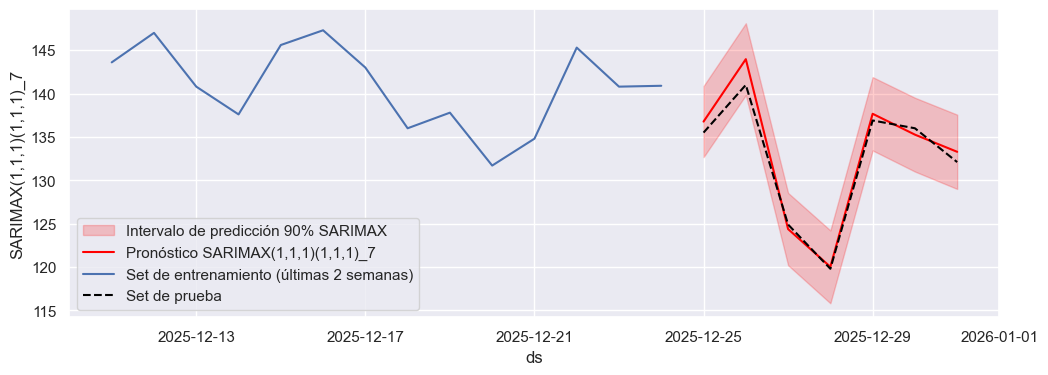

In [23]:
# Graficar
fig, ax = plt.subplots()

# ARIMAX: pronóstico puntual e intervalo de predicción
plt.fill_between(x=fc["ds"],
                 y1 = fc['SARIMAX(1,1,1)(1,1,1)_7-lo-90'],
                 y2 = fc['SARIMAX(1,1,1)(1,1,1)_7-hi-90'],
                 color = 'red',
                 alpha = 0.2,
                 label = 'Intervalo de predicción 90% SARIMAX');
sns.lineplot(fc, x="ds", y="SARIMAX(1,1,1)(1,1,1)_7", color='red', label='Pronóstico SARIMAX(1,1,1)(1,1,1)_7')

# Graficar últimas 2 semanas del set de entrenamiento así como el set de prueba original
sns.lineplot(df_tr[-14:], x="ds", y="y", label='Set de entrenamiento (últimas 2 semanas)')
sns.lineplot(df_ts, x="ds", y="y", label='Set de prueba', color='black', linestyle='--');

El pronóstico SARIMAX se ajusta bastante bien a los datos reales.

Y para generar un pronóstico nuevo seguimos estos pasos:

1. Creamos la instancia del modelo
2. Creamos un DataFrame **futuro** con las variables exógenas ("temperatura")
3. Generamos el pronóstico introduciendo al modelo **la totalidad de los datos** y **las variables exógenas**

Veamos esto paso a paso:

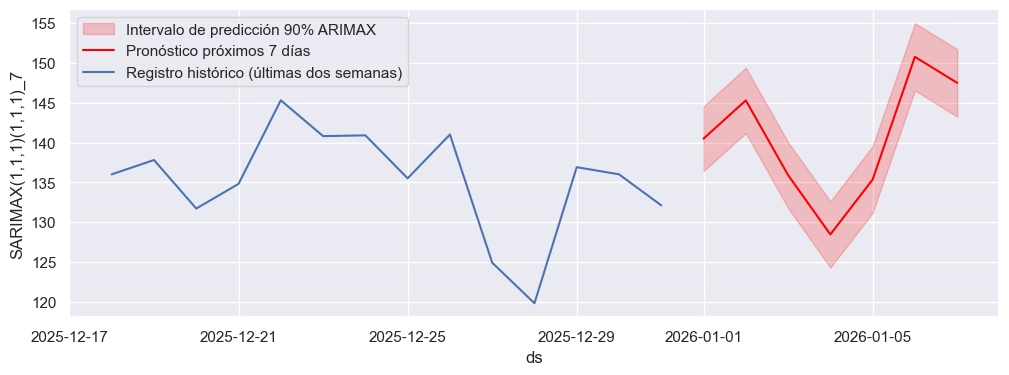

In [25]:
# Un nuevo pronóstico

# Instancia del modelo
models = [ARIMA(order=(1, 1, 1), 
                seasonal_order = (1,1,1),
                season_length = 7,
                alias='SARIMAX(1,1,1)(1,1,1)_7')]
sf = StatsForecast(models=models, freq='d')

# Crear dataframe FUTURO de variables exógenas
h = 7
fechas_futuras = pd.date_range(start=df['ds'].max() + pd.Timedelta(days=1), periods=h, freq='d')
X_df = pd.DataFrame({
    'unique_id': df['unique_id'].iloc[0], # El mismo unique_id del set de entrenamiento
    'ds': fechas_futuras,
    'temperatura': [13, 12, 11, 14, 15, 10, 11] # Supondremos estos niveles de temperatura para la próxima semana
})

# Pronosticar y graficar
fc = sf.forecast(df=df, X_df = X_df, h=7, level=[90])

fig, ax = plt.subplots()

plt.fill_between(x=fc["ds"],
                 y1 = fc['SARIMAX(1,1,1)(1,1,1)_7-lo-90'],
                 y2 = fc['SARIMAX(1,1,1)(1,1,1)_7-hi-90'],
                 color = 'red',
                 alpha = 0.2,
                 label = 'Intervalo de predicción 90% ARIMAX');
sns.lineplot(fc, x="ds", y="SARIMAX(1,1,1)(1,1,1)_7", color='red', label='Pronóstico próximos 7 días')

sns.lineplot(df[-14:], x="ds", y="y", label='Registro histórico (últimas dos semanas)');

¡Y listo, tenemos un modelo SARIMAX capaz de generar pronósticos a 7 días!

Como sugerencia adicional se recomienda validar el modelo en términos de su RMSE y su MAPE, usando validación cruzada.